In [8]:
import pandas as pd
# Create DataFrame (or load from Excel)
df = pd.DataFrame({
    "Specialty": [
        "Engineering","Engineering","Engineering","Pedagogy","Culture","Engineering",
        "Theology","Economics","Engineering","Philology","Comprehensive","Engineering",
        "Economics","Sport","Philology","Comprehensive","Economics","Law","Economics",
        "Comprehensive","Culture","Pedagogy","Engineering","Engineering","Engineering",
        "Medicine","Economics","Agricultural","Agricultural","Agricultural","Agricultural",
        "Agricultural","Agricultural","Agricultural","Agricultural","Medicine","Medicine",
        "Medicine","Medicine","Medicine","Medicine","Medicine"
    ],
    "FemalePercent": [
        16.56,18.90,54.55,80.95,83.33,20.00,
        42.86,77.42,32.73,79.55,65.41,33.33,
        20.00,45.83,80.00,45.16,37.70,34.69,16.67,
        100.00,33.33,100.00,27.27,0.00,33.71,
        70.64,36.71,42.03,33.33,50.00,83.33,
        88.89,33.33,75.00,40.00,100.00,33.33,
        100.00,100.00,68.97,100.00,63.64
    ]
})

In [9]:
def categorize(p):
    if p < 30:
        return "Low (<30%)"
    elif p < 60:
        return "Medium (30–60%)"
    else:
        return "High (>60%)"

df["FemaleCategory"] = df["FemalePercent"].apply(categorize)

In [10]:
ct = pd.crosstab(df["Specialty"], df["FemaleCategory"])

print(ct)

FemaleCategory  High (>60%)  Low (<30%)  Medium (30–60%)
Specialty                                               
Agricultural              3           0                5
Comprehensive             2           0                1
Culture                   1           0                1
Economics                 1           2                2
Engineering               0           5                4
Law                       0           0                1
Medicine                  7           0                1
Pedagogy                  2           0                0
Philology                 2           0                0
Sport                     0           0                1
Theology                  0           0                1


In [5]:
ct_norm = ct.div(ct.sum(axis=1), axis=0)
print(ct_norm)

FemaleCategory  High (>60%)  Low (<30%)  Medium (30–60%)
Program                                                 
Agricultural       0.375000    0.000000         0.625000
Comprehensive      0.666667    0.000000         0.333333
Culture            0.500000    0.000000         0.500000
Economics          0.200000    0.400000         0.400000
Engineering        0.000000    0.555556         0.444444
Law                0.000000    0.000000         1.000000
Medicine           0.875000    0.000000         0.125000
Pedagogy           1.000000    0.000000         0.000000
Philology          1.000000    0.000000         0.000000
Sport              0.000000    0.000000         1.000000
Theology           0.000000    0.000000         1.000000


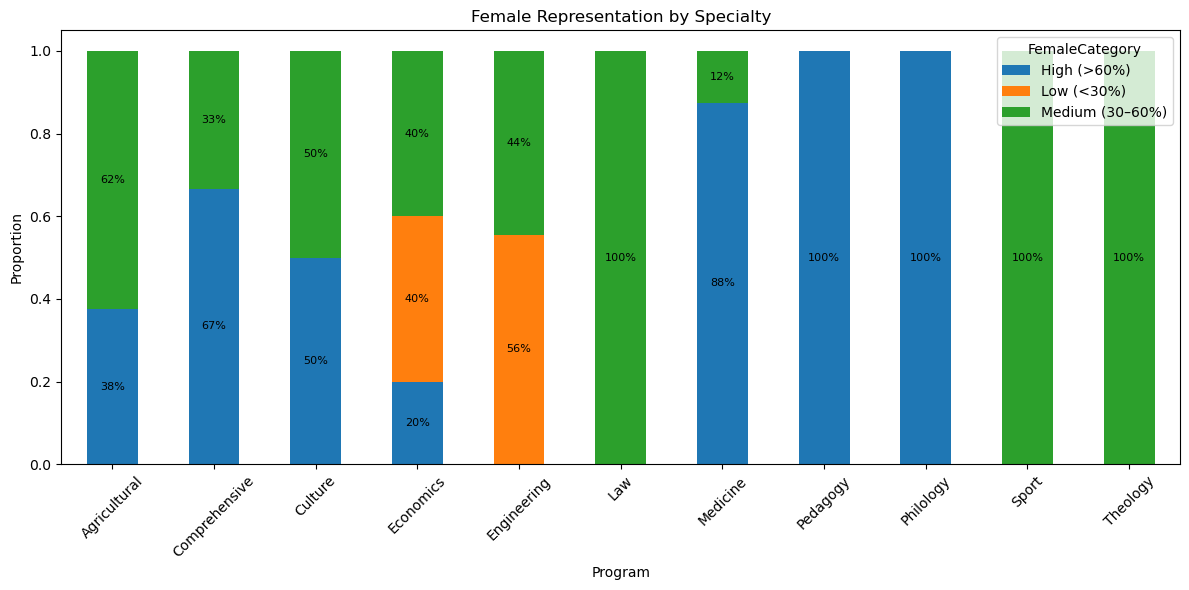

In [12]:
import matplotlib.pyplot as plt

ct_norm.plot(kind="bar", stacked=True, figsize=(12,6))

plt.title("Female Representation by Specialty")
plt.xlabel("Program")
plt.ylabel("Proportion")

plt.xticks(rotation=45)

# Add labels
for i, row in enumerate(ct_norm.values):
    cumulative = 0
    for val in row:
        if val > 0:
            plt.text(i, cumulative + val/2, f"{val:.0%}",
                     ha='center', va='center', fontsize=8)
            cumulative += val

plt.tight_layout()
plt.savefig("../figures/gender_balance.png", dpi=300)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency
# Create contingency table
ct = pd.crosstab(df["Program"], df["FemaleCategory"])

print("Contingency Table:")
print(ct)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print("\nChi-square statistic:", chi2)
print("p-value:", p)
print("Degrees of freedom:", dof)

# Expected frequencies
expected_df = pd.DataFrame(expected, 
                           index=ct.index, 
                           columns=ct.columns)

print("\nExpected Frequencies:")
print(expected_df)